# TuRBO Bayesian Optimization - Optimize
In this tutorial we demonstrate the use of Xopt to preform Trust Region Bayesian
Optimization (TuRBO) on a simple test problem. During optimization of high
dimensional input spaces off the shelf BO tends to over-emphasize exploration which
severely degrades optimization performance. TuRBO attempts to prevent this by
maintaining a surrogate model over a local (trust) region centered on the best
observation so far and restricting optimization inside that local region. The trust
region is expanded and contracted based on the number of `successful` (observations
that improve over the best observed point) or `unsuccessful` (no improvement)
observations in a row. See https://botorch.org/tutorials/turbo_1 for details.

## Define the test problem
Here we define a simple optimization problem, where we attempt to minimize a
function in the domian [0,2*pi]. Note that the function used to evaluate the
objective function takes a dictionary as input and returns a dictionary as the output.

In [1]:
from xopt.evaluator import Evaluator
from xopt.generators.bayesian import ExpectedImprovementGenerator
from xopt import Xopt
from xopt.vocs import VOCS
import math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# define variables and function objectives
vocs = VOCS(
    variables={"x": [0, 2 * math.pi]},
    objectives={"f": "MINIMIZE"},
)

/home/runner/work/Xopt/Xopt/.venv/lib/python3.12/site-packages/pyro/ops/stats.py:527: SyntaxWarning: invalid escape sequence '\g'
  we have :math:`ES^{*}(P,Q) \ge ES^{*}(Q,Q)` with equality holding if and only if :math:`P=Q`, i.e.


In [2]:
# define a test function to optimize
def sin_function(input_dict):
    x = input_dict["x"]
    return {"f": -10 * np.exp(-((x - np.pi) ** 2) / 0.01) + 0.5 * np.sin(5 * x)}

## Create Xopt objects
Create the evaluator to evaluate our test function and create a generator that uses
the Upper Confidence Bound acquisition function to perform Bayesian Optimization.

In [3]:
evaluator = Evaluator(function=sin_function)
generator = ExpectedImprovementGenerator(vocs=vocs, turbo_controller="optimize")
generator.gp_constructor.use_low_noise_prior = True

X = Xopt(evaluator=evaluator, generator=generator)

In [4]:
X

/home/runner/work/Xopt/Xopt/.venv/lib/python3.12/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Unexpected field `_initial_state`: Expected `OptimizeTurboController`)
  PydanticSerializationUnexpectedValue(Unexpected field `_initial_state`: Expected `OptimizeTurboController`)
  return self.__pydantic_serializer__.to_python(



            Xopt
________________________________
Version: 3.0.1
Data size: 0
Config as YAML:
dump_file: null
evaluator:
  function: __main__.sin_function
  function_kwargs: {}
  max_workers: 1
  vectorized: false
generator:
  computation_time: null
  custom_objective: null
  fixed_features: null
  gp_constructor:
    covar_modules: {}
    custom_noise_prior: null
    mean_modules: {}
    name: standard
    train_config: null
    train_kwargs: null
    train_method: lbfgs
    train_model: true
    trainable_mean_keys: []
    transform_inputs: true
    use_cached_hyperparameters: false
    use_low_noise_prior: true
  max_travel_distances: null
  model: null
  n_candidates: 1
  n_interpolate_points: null
  n_monte_carlo_samples: 128
  name: expected_improvement
  numerical_optimizer:
    max_iter: 2000
    max_time: 5.0
    n_restarts: 20
    name: LBFGS
  returns_id: false
  supports_batch_generation: true
  supports_constraints: true
  supports_single_objective: true
  turbo_controlle

## Generate and evaluate initial points
To begin optimization, we must generate some random initial data points. The first call
to `X.step()` will generate and evaluate a number of randomly points specified by the
 generator. Note that if we add data to xopt before calling `X.step()` by assigning
 the data to `X.data`, calls to `X.step()` will ignore the random generation and
 proceed to generating points via Bayesian optimization.

In [5]:
X.evaluate_data(pd.DataFrame({"x": [3.0, 1.75, 2.0]}))

# inspect the gathered data
X.data

,x,f,xopt_runtime,xopt_error
0,3.00,-1.021664,0.000021,False
1,1.75,0.312362,0.000004,False
2,2.00,-0.272011,0.000003,False


In [6]:
# determine trust region from gathered data
X.generator.train_model()
X.generator.turbo_controller.update_state(X.generator)
X.generator.turbo_controller.get_trust_region(X.generator)

tensor([[2.2146],
        [3.7854]])

## Define plotting utility

In [7]:
def plot_turbo(X):
    # get the Gaussian process model from the generator
    model = X.generator.train_model()

    # get trust region
    trust_region = X.generator.turbo_controller.get_trust_region(generator).squeeze()
    scale_factor = X.generator.turbo_controller.length
    region_width = trust_region[1] - trust_region[0]
    best_value = X.generator.turbo_controller.best_value

    # get acquisition function from generator
    acq = X.generator.get_acquisition(model)

    # calculate model posterior and acquisition function at each test point
    # NOTE: need to add a dimension to the input tensor for evaluating the
    # posterior and another for the acquisition function, see
    # https://botorch.org/docs/batching for details
    # NOTE: we use the `torch.no_grad()` environment to speed up computation by
    # skipping calculations for backpropagation
    with torch.no_grad():
        posterior = model.posterior(test_x.unsqueeze(1))
        acq_val = acq(test_x.reshape(-1, 1, 1))

    # get mean function and confidence regions
    mean = posterior.mean
    L, u = posterior.mvn.confidence_region()

    # plot model and acquisition function
    fig, ax = plt.subplots(2, 1, sharex="all")

    # add title for successes and failures
    ax[0].set_title(
        f"scale_factor: {scale_factor}, region_width: {region_width:.2}, "
        f"best_value: {best_value:.4}"
    )

    # plot model posterior
    ax[0].plot(test_x, mean, label="Posterior mean")
    ax[0].fill_between(test_x, L, u, alpha=0.25, label="Confidence region")

    # add data to model plot
    ax[0].plot(X.data["x"], X.data["f"], "C1o", label="Training data")

    # plot true function
    true_f = sin_function({"x": test_x})["f"]
    ax[0].plot(test_x, true_f, "--", label="Ground truth")

    # plot acquisition function
    ax[1].plot(test_x, acq_val.flatten().exp())

    ax[0].set_ylabel("f")
    ax[0].set_ylim(-12, 10)
    ax[1].set_ylabel(r"$\alpha(x)$")
    ax[1].set_xlabel("x")

    # plot trust region
    for a in ax:
        a.axvline(trust_region[0], c="r", label="Trust region boundary")
        a.axvline(trust_region[1], c="r")

    # add legend
    ax[0].legend(fontsize="x-small")

    fig.tight_layout()

    return fig, ax

## Do bayesian optimization steps
Notice that when the number of successive successes or failures reaches 2 the trust
region expands or contracts and counters are reset to zero. Counters are also reset
to zero during alternate successes/failures. Finally, the model is most accurate
inside the trust region, which supports our goal of local optimization.

/tmp/ipykernel_3435/2233511880.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"f": -10 * np.exp(-((x - np.pi) ** 2) / 0.01) + 0.5 * np.sin(5 * x)}


/tmp/ipykernel_3435/2233511880.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"f": -10 * np.exp(-((x - np.pi) ** 2) / 0.01) + 0.5 * np.sin(5 * x)}


/tmp/ipykernel_3435/2233511880.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"f": -10 * np.exp(-((x - np.pi) ** 2) / 0.01) + 0.5 * np.sin(5 * x)}


/tmp/ipykernel_3435/2233511880.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"f": -10 * np.exp(-((x - np.pi) ** 2) / 0.01) + 0.5 * np.sin(5 * x)}


/tmp/ipykernel_3435/2233511880.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"f": -10 * np.exp(-((x - np.pi) ** 2) / 0.01) + 0.5 * np.sin(5 * x)}


...

/tmp/ipykernel_3435/2233511880.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"f": -10 * np.exp(-((x - np.pi) ** 2) / 0.01) + 0.5 * np.sin(5 * x)}


/tmp/ipykernel_3435/2233511880.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"f": -10 * np.exp(-((x - np.pi) ** 2) / 0.01) + 0.5 * np.sin(5 * x)}


/tmp/ipykernel_3435/2233511880.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"f": -10 * np.exp(-((x - np.pi) ** 2) / 0.01) + 0.5 * np.sin(5 * x)}


/tmp/ipykernel_3435/2233511880.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"f": -10 * np.exp(-((x - np.pi) ** 2) / 0.01) + 0.5 * np.sin(5 * x)}


/tmp/ipykernel_3435/2233511880.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return {"f": -10 * np.exp(-((x - np.pi) ** 2) / 0.01) + 0.5 * np.sin(5 * x)}


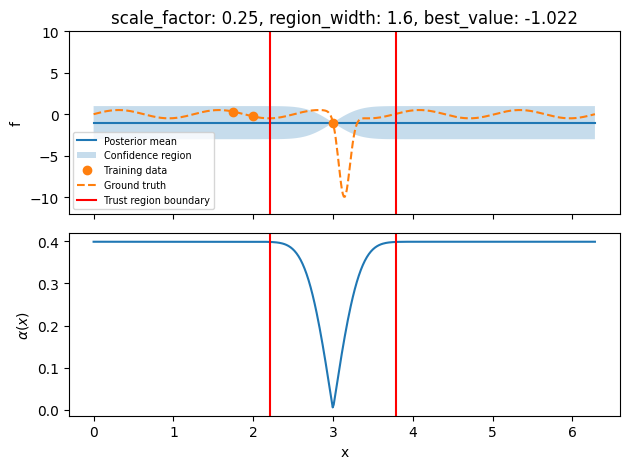

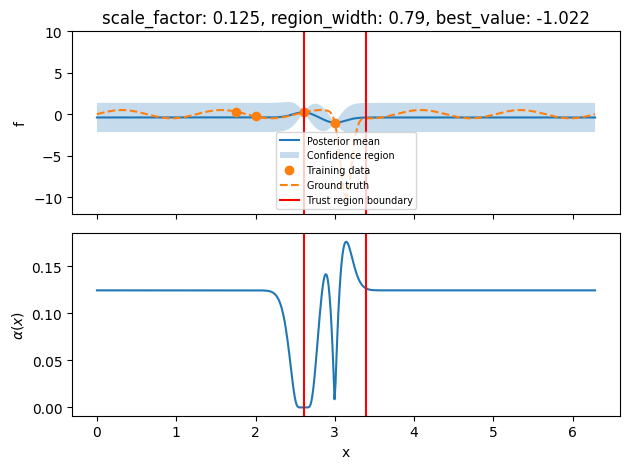

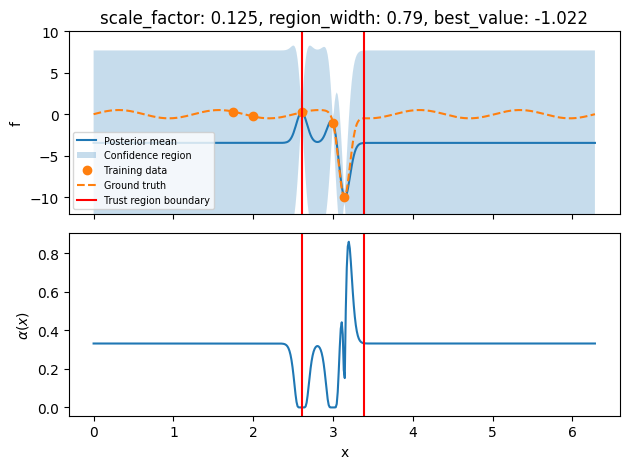

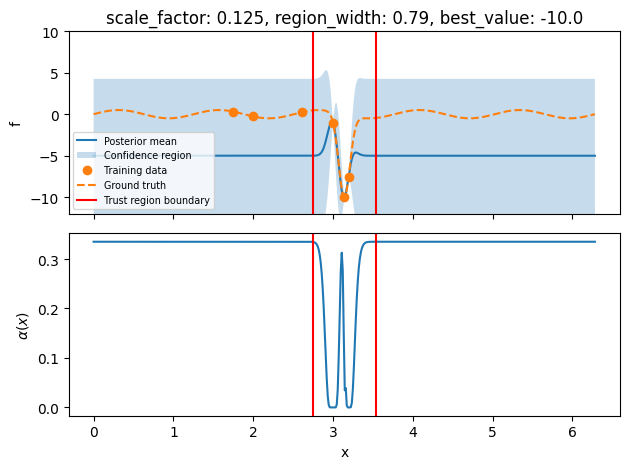

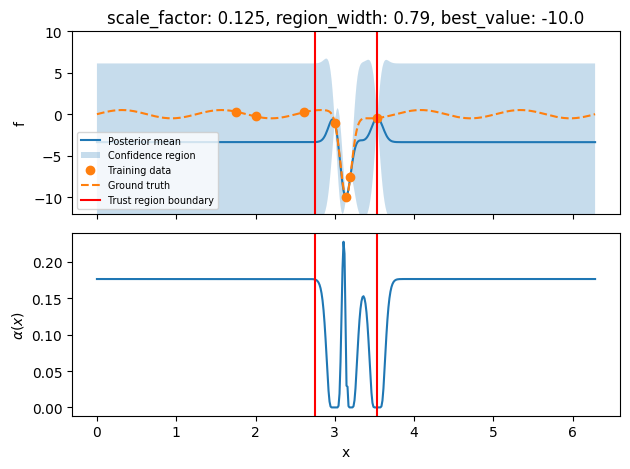

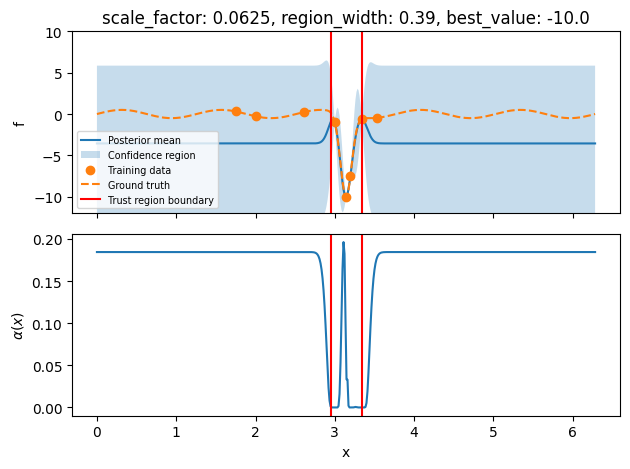

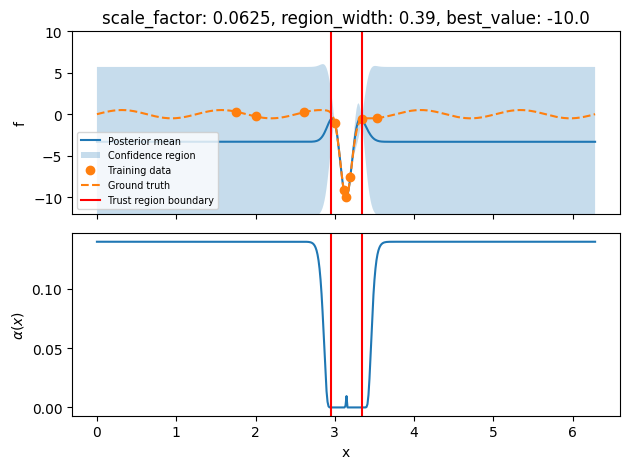

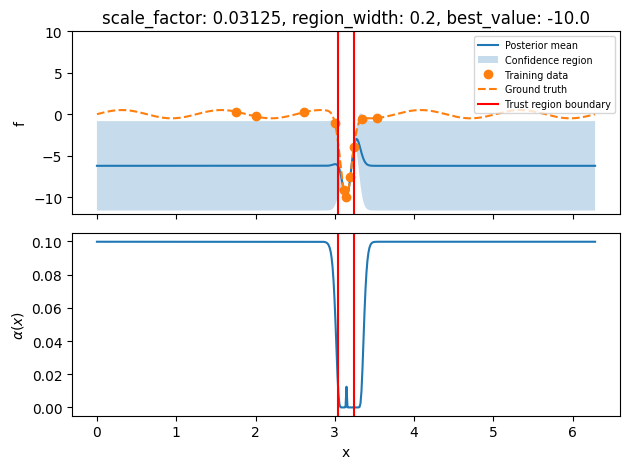

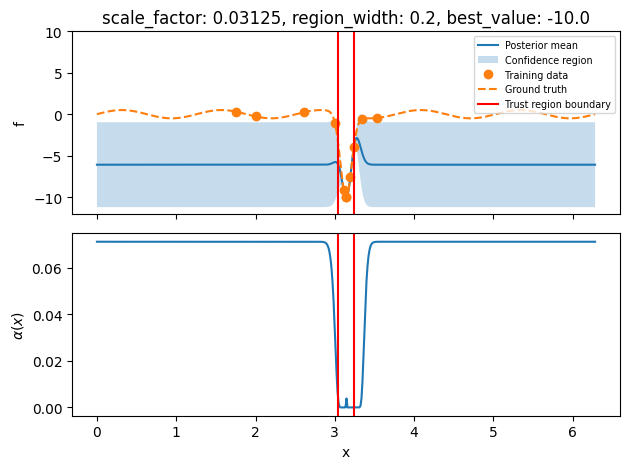

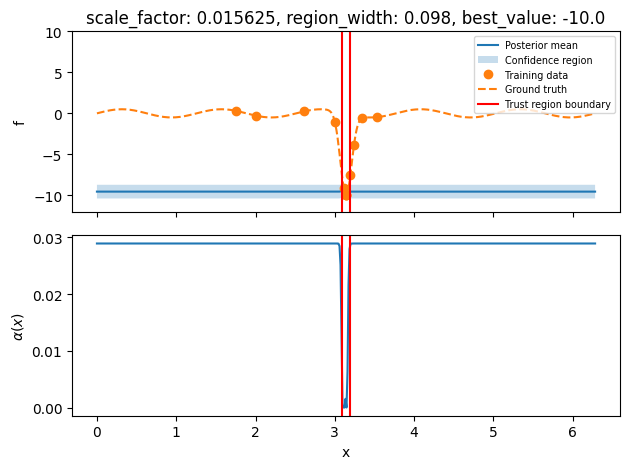

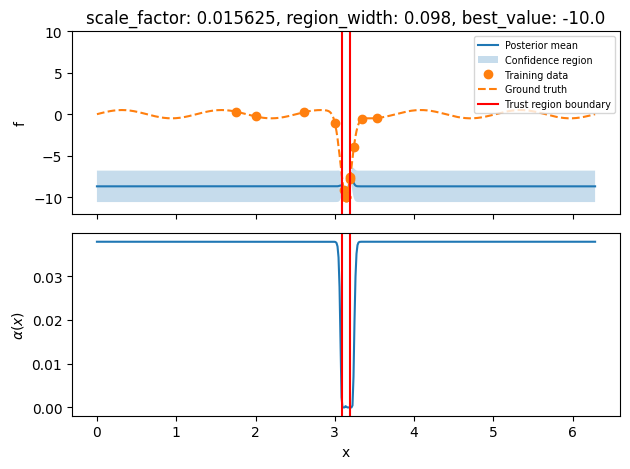

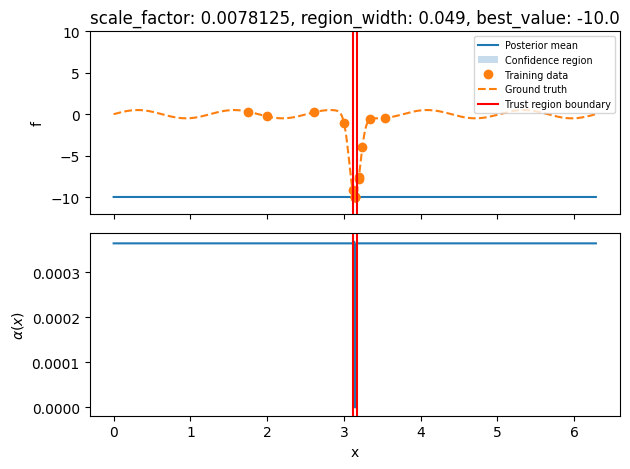

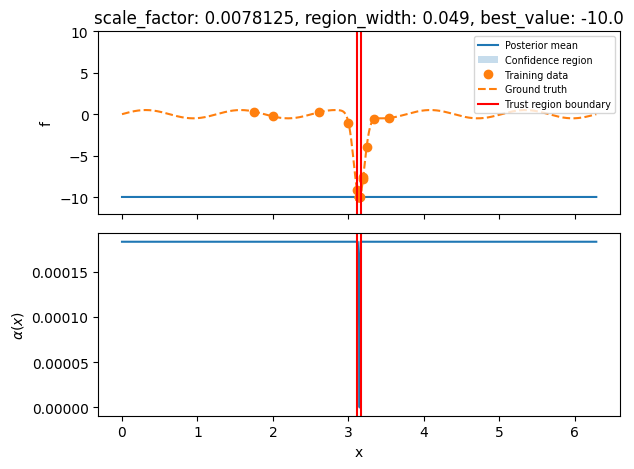

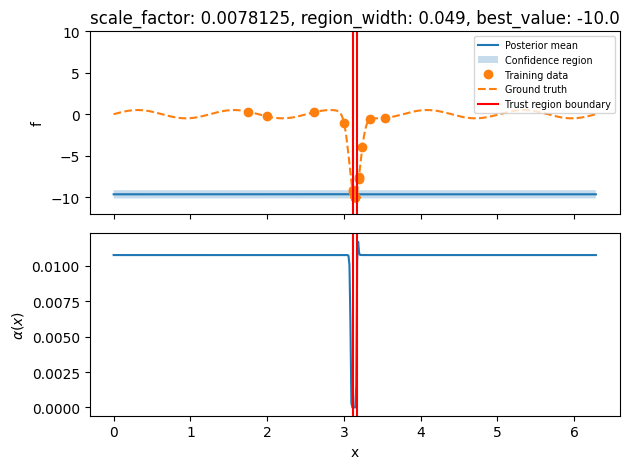

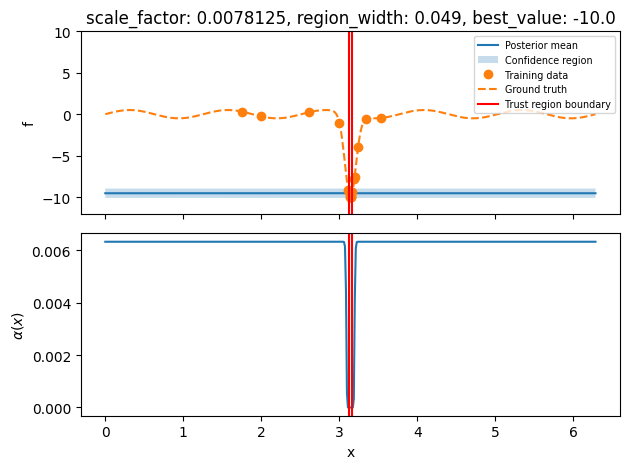

In [8]:
# test points for plotting
test_x = torch.linspace(*torch.tensor(X.vocs.bounds).flatten(), 500).double()

for i in range(15):
    # plot trust region analysis
    fig, ax = plot_turbo(X)

    # take optimization state
    X.step()

In [9]:
# access the collected data
X.generator.turbo_controller

OptimizeTurboController(vocs=VOCS(variables={'x': ContinuousVariable(dtype=None, default_value=None, domain=[0.0, 6.283185307179586])}, objectives={'f': MinimizeObjective(dtype=None)}, constraints={}, constants={}, observables={}), batch_size=1, length=0.0078125, length_min=0.0078125, length_max=2.0, failure_tolerance=2, success_tolerance=2, center_x={'x': 3.1422400809684587}, scale_factor=2.0, restrict_model_data=True, name='OptimizeTurboController', best_value=np.float64(-10.001199412193902), dim=1)

In [10]:
X.data

,x,f,xopt_runtime,xopt_error
0,3.000000,-1.021664,0.000021,False
1,1.750000,0.312362,0.000004,False
2,2.000000,-0.272011,0.000003,False
3,2.607301,0.226503,0.000021,False
4,3.143638,-10.000931,0.000012,False
5,3.196329,-7.546244,0.000011,False
6,3.536337,-0.459961,0.000011,False
7,3.339987,-0.613808,0.000012,False
8,3.113320,-9.161297,0.000013,False
9,3.241812,-3.902846,0.000012,False
